In [ ]:
%load_ext autoreload
%autoreload 2

# Importing required modules and subpackages

For this example, the required subpackages from `oceanicospy` are imported, as well as some standard libraries for plotting and data manipulation.

In [ ]:
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
mpl.rcParams["font.size"] = 12

In [ ]:
from oceanicospy.observations import AQUAlogger,RBR
from oceanicospy.analysis import spectral

# Pressure data

Deployment data from pressure sensors is loaded as a dictionary, while the sensor data is read from the corresponding sensor files. It has to be clarified that sensors are not deployed either at the same time or location.

In [5]:
measurement_pressure_sensors_paths = ['../data/observations/AQ/','../data/observations/RBR/']

sampling_AQ = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=1,burst_length_s=2048,temperature=False,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=1))
sampling_RBR = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=2,burst_length_s=7200,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=0.5))

Each type of sensor is treated as a object and its methods are used to retrieve the raw and clean data. For further information about how to upload the sensor data using **oceanicospy**, please refer to the [data loading example](https://oceanicospy.readthedocs.io/en/latest/examples/data_loading.html).

In [6]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict()

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    if 'AQ' in measurement_path:
        object_device = AQUAlogger(measurement_path, sampling_data[idx])
    else:
        object_device = RBR(measurement_path,sampling_data[idx])

    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

A quick look at the data shows that the pressure signal is sampled at 1Hz for the AQ sensor and 2Hz for the RBR sensor.

In [7]:
dict_clean_measurements['RBR']

,pressure[bar],depth[m],burstId,eta[m]
date,,,,
2025-05-09 10:00:00.000,1.241829,2.267149,1,0.117985
2025-05-09 10:00:00.500,1.239702,2.246051,1,0.096886
2025-05-09 10:00:01.000,1.235314,2.202530,1,0.053365
2025-05-09 10:00:01.500,1.233978,2.189276,1,0.040110
2025-05-09 10:00:02.000,1.234466,2.194119,1,0.044954
...,...,...,...,...
2025-05-19 17:59:57.500,1.228489,2.134836,248,-0.044336
2025-05-19 17:59:58.000,1.228343,2.133389,248,-0.045786
2025-05-19 17:59:58.500,1.226372,2.113838,248,-0.065340


In [8]:
dict_clean_measurements['AQ']

,pressure[bar],Raw2,depth[m],depth_aux[m],burstId,eta[m]
date,,,,,,
2025-05-09 10:00:00,1.245722,0,3.136509,2.307327,1,0.052596
2025-05-09 10:00:01,1.244709,0,3.124966,2.297273,1,0.041052
2025-05-09 10:00:02,1.237181,0,3.039040,2.222556,1,-0.044874
2025-05-09 10:00:03,1.243695,0,3.113418,2.287209,1,0.029503
2025-05-09 10:00:04,1.253249,0,3.222086,2.382034,1,0.138170
...,...,...,...,...,...,...
2025-05-19 16:34:03,1.239498,0,3.065513,2.245553,124,-0.003209
2025-05-19 16:34:04,1.242248,0,3.096910,2.272847,124,0.028177
2025-05-19 16:34:05,1.237905,0,3.047316,2.229742,124,-0.021427


# Using the `WaveSpectralAnalyzer` class

First, we need to instanciate the `WaveSpectralAnalyzer` class, which will allow us to make the spectral analysis for the surface elevation data (originally taken from the pressure records). We need to provide the measured signal and the sampling data as arguments.

`WaveSpectralAnalyzer` will look for measuremed signal as a **pandas DataFrame** with a column named "eta[m]", which is the standard name for the sea surface elevation in **oceanicospy**. If the column name is different, it can be specified as an argument when instanciating the class.

In [9]:
help(spectral.WaveSpectralAnalyzer)

Help on class WaveSpectralAnalyzer in module oceanicospy.analysis.spectral:

class WaveSpectralAnalyzer(builtins.object)
 |  WaveSpectralAnalyzer(measured_signal, sampling_data, surface_level_column='eta[m]', logger=True)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, measured_signal, sampling_data, surface_level_column='eta[m]', logger=True)
 |      Initializes the analysis object with measurement signal and sampling data.
 |      
 |      Parameters
 |      ----------
 |      measured_signal : array-like
 |          The input signal data to be analyzed.
 |      sampling_data : dict
 |          Dictionary containing sampling parameters with the following keys:
 |              - 'sampling_freq' (float): Sampling frequency of the signal.
 |              - 'anchoring_depth' (float): Depth at which the sensor is anchored.
 |              - 'sensor_height' (float): Height of the sensor above the bottom.
 |              - 'burst_length_s' (float): Duration of each burst in seconds.


## Welch's and FFT method

First, we can use the `get_spectra_and_params_for_bursts` method to compute the spectra and wave parameters for the bursts in the data. This method has two options to process the data in spectral terms: Welch's method and FFT. 

In [11]:
dict_spectra_welch = dict()
dict_integral_params_welch = dict()
dict_spectra_fft = dict()
dict_integral_params_fft = dict()

for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    spectra_welch,params_welch = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='welch',kp_correction=False,ig_split=True,
                                                                                        freq_split=0.04, window_type='hamming',
                                                                                        window_length=1024,overlap=512,smoothing_bins=6)
    spectra_fft,params_fft = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='fft',kp_correction=False,ig_split=True,
                                                                                    freq_split=0.04)

    dict_spectra_welch[metadata_list[idx]] = spectra_welch
    dict_integral_params_welch[metadata_list[idx]] = params_welch
    dict_spectra_fft[metadata_list[idx]] = spectra_fft
    dict_integral_params_fft[metadata_list[idx]] = params_fft

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


### Plotting random bursts and their corresponding spectra

The time series and spectra for a random burst are plotted for each sensor and method. The spectra are plotted in log scale to better visualize the different frequency components.

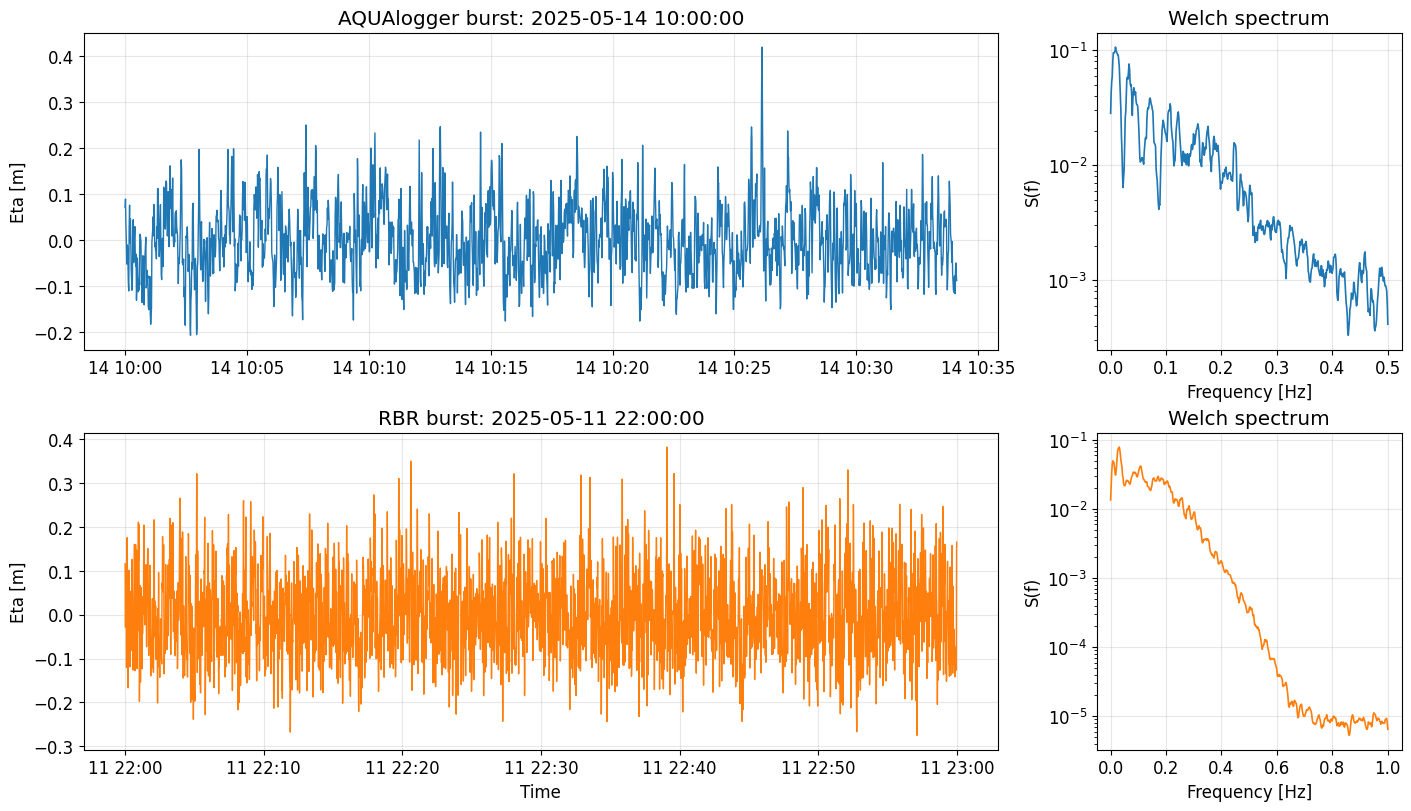

In [23]:
burst_to_plot = 61

AQ_df = dict_clean_measurements["AQ"]
RBR_df = dict_clean_measurements["RBR"]

AQ_burst = AQ_df[AQ_df["burstId"] == burst_to_plot]
RBR_burst = RBR_df[RBR_df["burstId"] == burst_to_plot]

AQ_freq = dict_spectra_welch["AQ"]["freq"]
RBR_freq = dict_spectra_welch["RBR"]["freq"]
AQ_S = dict_spectra_welch["AQ"]["S"][burst_to_plot-1]
RBR_S = dict_spectra_welch["RBR"]["S"][burst_to_plot-1]

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 4)

ax_AQ_timeseries = fig.add_subplot(gs[0, 0:3])
ax_AQ_spectra = fig.add_subplot(gs[0, 3])
ax_RBR_timeseries = fig.add_subplot(gs[1, 0:3])
ax_RBR_spectra = fig.add_subplot(gs[1, 3])

# AQ time series
ax_AQ_timeseries.plot(AQ_burst["eta[m]"], lw=1.0)
ax_AQ_timeseries.set(ylabel="Eta [m]",title = f"AQUAlogger burst: {AQ_burst.index[0].strftime('%Y-%m-%d %H:%M:%S')}")
ax_AQ_timeseries.grid(True, alpha=0.3)

# AQ spectrum
ax_AQ_spectra.plot(AQ_freq, AQ_S, lw=1.2)
ax_AQ_spectra.set(xlabel="Frequency [Hz]", ylabel="S(f)", title="Welch spectrum", yscale="log")
ax_AQ_spectra.grid(True, alpha=0.3)

# RBR time series
ax_RBR_timeseries.plot(RBR_burst.index, RBR_burst["eta[m]"], lw=1.0, color="tab:orange")
ax_RBR_timeseries.set(xlabel="Time", ylabel="Eta [m]",title=f"RBR burst: {RBR_burst.index[0].strftime('%Y-%m-%d %H:%M:%S')}")
ax_RBR_timeseries.grid(True, alpha=0.3)

# RBR spectrum
ax_RBR_spectra.plot(RBR_freq, RBR_S, lw=1.2, color="tab:orange")
ax_RBR_spectra.set(xlabel="Frequency [Hz]", ylabel="S(f)", title="Welch spectrum", yscale="log")
ax_RBR_spectra.grid(True, alpha=0.3)
# plt.show()

Note that the upper limit for each spectra is different for each sensor, followingthe Nyquist theorem. The AQ sensor has a sampling frequency of 1Hz, while the RBR sensor has a sampling frequency of 2Hz.

## Wavelets transform

Another feature of the `WaveSpectralAnalyzer` class is the possibility to compute the wavelet transform of the signal, which allows to analyze the signal in both time and frequency domains. The `compute_wavelet_scalograms` method allows to compute wavelets coefficient given a mother wavelet and a range of scales. Methods to compute the scalogram for each burst and continuous data are currently supported.

In [24]:
help(spectral.WaveSpectralAnalyzer.compute_wavelet_scalograms)

Help on function compute_wavelet_scalograms in module oceanicospy.analysis.spectral:

compute_wavelet_scalograms(self, mother_wavelet, points_scale, burst_mode=False, window_length=None, overlap=None)
    Compute wavelet scalograms for all bursts in the measurement signal.
    
    Parameters
    ----------
    mother_wavelet : str
        The mother wavelet to use (e.g., 'morl', 'cmor', etc.).
    points_scale : int
        The number of frequency points
    burst_mode : bool, optional
        If True, computes scalograms for each burst separately using overlapping windows. Default is False.
        If False, computes a single scalogram for the entire measurement signal without windowing.
    window_length : int, optional
        The length of each window in samples (required if burst_mode is True). Default is None.
    overlap : float, optional
        The overlap between consecutive windows (required if burst_mode is True). Default is None.
    
    Returns
    -------
    coefs_all

In [33]:
dict_coef_wavelets = dict()
dict_freqs_wavelets = dict()
for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    if 'AQ' in metadata:   
        coef_wavelets,freqs_wavelets = SpectralAnalyzer.compute_wavelet_scalograms(mother_wavelet='cmor1.5-1.0',points_scale=50,burst_mode=True,
                                                                                   window_length=sampling_data[idx]['burst_length_s'],overlap=1)
        coef_wavelets = np.stack(coef_wavelets, axis=0)
        coef_wavelets_full  = coef_wavelets.transpose(1, 0, 2).reshape(len(freqs_wavelets), -1)
    else:
        coef_wavelets_full,freqs_wavelets = SpectralAnalyzer.compute_wavelet_scalograms(mother_wavelet='cmor1.5-1.0',points_scale=50)
    dict_coef_wavelets[metadata_list[idx]] = coef_wavelets_full
    dict_freqs_wavelets[metadata_list[idx]] = freqs_wavelets

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


A quick look at the dictionaty that constains the wavelet coefficients and frequencies shows that the wavelet transform has been computed for both sensors. The frequencies are also stored in a separate dictionary.

For the AQ sensor, the original expected shape of the wavelet coefficients is `(number of bursts, number of frequencies, number of time points in each burst)`, but the coefficients are reshaped to have a shape of `(number of frequencies, number of time points across all bursts)` to be able to compare it with the RBR sensor.

The expected shape for RBR is `(number of frequencies, number of time points in the continuous signal)`.

In [34]:
dict_coef_wavelets['AQ'].shape

(50, 253952)

In [35]:
dict_coef_wavelets['RBR'].shape

(50, 1785600)

### Plotting the wavelet scalogram

Because of length of the signal, this plot might take a while to be generated. The upper plot shows the wavelet scalogram for the AQ sensor, while the lower plot shows the scalogram for the RBR sensor. The gaps in the AQ scalogram are due to the fact that the wavelet transform was computed for each burst, while the RBR scalogram is continuous. The colorbar shows the magnitude of the wavelet coefficients in log scale. The frequencies are plotted in log scale to better visualize the different frequency components.

In [55]:
fig,[ax1, ax2] = plt.subplots(2,1,figsize=(14,6))

for idx, key in enumerate(list(dict_coef_wavelets.keys())):
    print(key)

    # ---- Computing time dimension ---------- #
    sampling = sampling_data[idx]
    if 'AQ' in key:
        start_time = sampling['start_time']
        end_time = sampling['end_time']
        time_full = pd.date_range(start=start_time, end=end_time, freq='1s')    
    else:
        time = pd.date_range(start=sampling['start_time'], end=sampling['end_time'], freq=f'{int(1000/sampling["sampling_freq"])}ms')
    # ---- Computing time dimension ---------- #

    periods = 1.0 / dict_freqs_wavelets['RBR']
    seconds_per_burst = 7200
    valid_per_burst = 2048

    if 'AQ' in key:
        n_bursts = dict_coef_wavelets['AQ'].shape[1] // valid_per_burst

        full_blocks = []
        for b in range(n_bursts):
            start = b * valid_per_burst
            end = (b + 1) * valid_per_burst
            block_valid = dict_coef_wavelets['AQ'][:, start:end] # shape (n_freqs, 2048)
            block_full = np.full((dict_coef_wavelets['AQ'].shape[0], seconds_per_burst), np.nan)
            block_full[:, :valid_per_burst] = block_valid
            full_blocks.append(block_full)

        coeffs_full = np.hstack(full_blocks)  
    
        cmap = plt.cm.magma_r.copy()
        cmap.set_bad('white')
        cax = ax1.pcolormesh(time_full,periods,coeffs_full,cmap=cmap,vmin=0,vmax=0.3,shading='auto')
        ax1.set(ylabel='Period [s]',yscale='log',ylim=(1000,5),yticks=[1000,100,10],yticklabels=['1000','100','10'])
        cbar_ax = fig.add_axes([0.4, 0.01, 0.3, 0.01])  # [left, bottom, width, height]
        cb = plt.colorbar(cax, cax=cbar_ax,extend='max',orientation='horizontal')
        cb.set_label('S [$m^2s$]', labelpad=0.1)
        cb.set_ticks([0, 0.1, 0.2, 0.3])
    else:
        cax = ax2.pcolormesh(time,periods,dict_coef_wavelets['RBR'],cmap='magma_r',vmin=0,vmax=0.3,shading='auto')
        ax2.set(ylabel='Period [s]',yscale='log',ylim=(1000,1),yticks=[1000,100,10,1],yticklabels=['1000','100','10','1'])


AQ
RBR


: 